# DiffPIR / DPS / Plug-and-Play comparison

This notebook is a unified playground for comparing:

- DiffPIR
- DPS variants (`DPS_y0`, `DPS_yt`)
- Plug-and-play methods with other priors (e.g. DRUNet)

across the three tasks:

- Super-resolution (SISR)
- Deblurring
- Inpainting

Some method functions are **stubs** that currently raise `NotImplementedError`.
Once you implement them (see `EXPERIMENTS_IMPLEMENTATION_GUIDE.md`), the cells
below will run end-to-end.


In [1]:
import os
from pathlib import Path
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt

from experiments.common import MethodConfig, RunResult, run_experiment, load_image_paths
from experiments import pnp_priors
from experiments import sr_methods, deblur_methods, inpaint_methods


In [ ]:
# Registry of available per-image methods for each task.

def get_sr_methods():
    return {
        "diffpir": sr_methods.run_diffpir_sr,
        "dps_y0": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_yt"),
        # Enable this once you implement run_pnp_drunet_sr
        "pnp_drunet": sr_methods.run_pnp_drunet_sr,
    }


def get_deblur_methods():
    return {
        "diffpir": deblur_methods.run_diffpir_deblur,
        "dps_y0": lambda img, cfg: deblur_methods.run_dps_deblur(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: deblur_methods.run_dps_deblur(img, cfg, mode="DPS_yt"),
        "pnp_drunet": deblur_methods.run_pnp_drunet_deblur,
    }


def get_inpaint_methods():
    return {
        "diffpir": inpaint_methods.run_diffpir_inpaint,
        "dps_y0": lambda img, cfg: inpaint_methods.run_dps_inpaint(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: inpaint_methods.run_dps_inpaint(img, cfg, mode="DPS_yt"),
        "pnp_drunet": inpaint_methods.run_pnp_drunet_inpaint,
    }


METHOD_REGISTRY = {
    "sr": get_sr_methods(),
    "deblur": get_deblur_methods(),
    "inpaint": get_inpaint_methods(),
}


def _default_method_config(task: str, name: str) -> MethodConfig:
    """Create a simple MethodConfig for a given task/method name."""

    if name.startswith("dps_"):
        generate_mode = name.upper()  # "DPS_Y0" / "DPS_YT" variants
    elif name == "diffpir":
        generate_mode = "DiffPIR"
    else:
        generate_mode = name  # e.g. "pnp_drunet"

    return MethodConfig.load_from_yaml(
        os.path.join("configs", f"{task}.yaml"),
        name
    )


def compare_task(
    task: str,
    testset_root: str,
    methods: List[str],
) -> Dict[str, RunResult]:
    """Run all selected methods for a given task over a dataset.

    Returns a dict mapping method name -> RunResult.
    """

    image_paths = load_image_paths(testset_root)
    task_methods = METHOD_REGISTRY[task]
    results: Dict[str, RunResult] = {}

    for name in methods:
        if name not in task_methods:
            raise ValueError(f"Unknown method '{name}' for task '{task}'")
        method_fn = task_methods[name]
        cfg = _default_method_config(task=task, name=name)
        print(cfg)
        run_result = run_experiment(
            method_config=cfg,
            image_paths=image_paths,
            method_fn=method_fn,
            output_root=None,
        )
        results[name] = run_result
    return results


def plot_metric_bar(results: Dict[str, RunResult], metric: str = "average_psnr", title: str = ""):
    """Plot a bar chart of a given aggregate metric for each method."""

    methods = list(results.keys())
    values = [float(getattr(results[m], metric)) for m in methods]

    plt.figure(figsize=(6, 4))
    plt.bar(methods, values)
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


In [ ]:
# Hyper parameters tuning
# Let's try to find best lambda for deblurring
def best_lambda_deblur():
    # Load the deblur config
    config = MethodConfig.load_from_yaml(os.path.join("configs", "deblur.yaml"))
    best_lambda = None
    best_psnr = 0
    # Run the deblur experiment for a range of lambdas
    for lambda_ in np.arange(1, 5):
        deblur_results = compare_task(
            task="deblur",
            testset_root="testsets/demo_test",
            methods=["diffpir"],
            sf=1,
            lambda_=lambda_,
        )
        # Get the average PSNR of the deblur results
        average_psnr = deblur_results["diffpir"].average_psnr
        print(f"Lambda: {lambda_}, Average PSNR: {average_psnr}")
        if average_psnr > best_psnr:
            best_psnr = average_psnr
            best_lambda = lambda_
    print(f"Best lambda: {best_lambda}, Best PSNR: {best_psnr}")
    return best_lambda, best_psnr

best_lambda_deblur()

[2026-03-06 17:57:03,700][diffpir_deblur.69037][INFO] Starting DiffPIR deblurring | img=69037 | lambda=2.000 | zeta=0.250 | noise=0.0500 | model=diffusion_ffhq_10m


MethodConfig(task='deblur', generate_mode='DiffPIR', lambda_=2, zeta=0.25, sf=1, extra={'seed': 42, 'noise_level_img': 0.05, 'noise_level_model': 'noise_level_img', 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'iter_num': 100, 'iter_num_U': 1, 'batch_size': 16, 'save_L': True, 'save_E': True, 'sub_1_analytic': True, 'log_process': False, 'ddim_sample': False, 'model_output_type': 'pred_xstart', 'skip_type': 'quad', 'eta': 0, 'guidance_scale': 1.0, 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'beta_start': 0.0001, 'beta_end': 0.02, 'noise_init_img': 'max', 'skip_noise_model_t': False, 'use_DIY_kernel': True, 'blur_mode': 'Gaussian', 'kernel_size': 61})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[2026-03-06 17:57:05,422][diffpir_deblur.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-06 17:57:05,443][diffpir_deblur.69037][INFO] Blur kernel: mode=Gaussian | kernel_size=61 | kernel_std≈3.000
[2026-03-06 17:57:05,444][diffpir_deblur.69037][INFO] Applying blur and AWGN (σ≈0.0500)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


[2026-03-06 17:57:06,031][diffpir_deblur.69037][INFO] Starting reverse diffusion (100 steps, skip_type=quad)
DiffPIR Deblurring: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]
[2026-03-06 17:58:17,604][diffpir_deblur.69037][INFO] Reverse diffusion finished for 69037
[2026-03-06 17:58:17,763][diffpir_deblur.69037][INFO] Results | img=69037 | PSNR=22.434 dB | LPIPS=0.3338
[2026-03-06 17:58:17,767][diffpir_deblur.69037][INFO] Saved restored image to outputs/diffpir_deblur/69037_diffpir.png
[2026-03-06 17:58:17,770][diffpir_deblur.69037][INFO] Saved LR image to outputs/diffpir_deblur/69037_LR.png
[2026-03-06 17:58:17,784][diffpir_deblur.69133][INFO] Starting DiffPIR deblurring | img=69133 | lambda=2.000 | zeta=0.250 | noise=0.0500 | model=diffusion_ffhq_10m


...

Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


[2026-03-06 18:03:03,930][pnp_deblur.69929][INFO] Using DRUNet denoiser from 
PnP Deblurring: 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-06 18:03:07,519][pnp_deblur.69929][INFO] Results | img=69929 | PSNR=23.772 dB | LPIPS=0.4238
[2026-03-06 18:03:07,522][pnp_deblur.69929][INFO] Saved restored image to outputs/pnp_deblur/69929_pnp_drunet.png
[2026-03-06 18:03:07,526][pnp_deblur.69929][INFO] Saved LR image to outputs/pnp_deblur/69929_LR.png


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


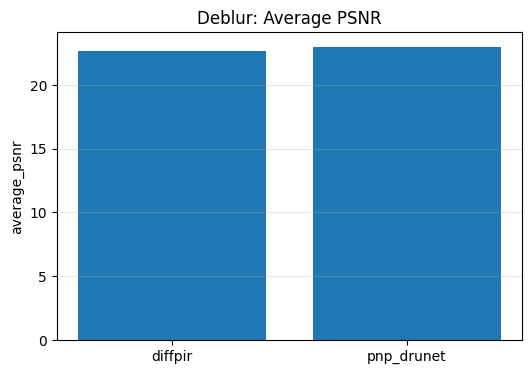

In [3]:
# Deblurring comparison
deblur_results = compare_task(
    task="deblur",
    testset_root="testsets/demo_test",
    methods=["diffpir", "pnp_drunet"],  # diffpir, "dps_y0", "dps_yt"
)
plot_metric_bar(deblur_results, metric="average_psnr", title="Deblur: Average PSNR")

In [ ]:
# Super-resolution comparison on the demo_test set
# sr_results = compare_task(
#     task="sr",
#     testset_root="testsets/demo_test",
#     methods=["diffpir", "dps_y0", "dps_yt"],  # add "pnp_drunet" once implemented
#     sf=4,
# )
# plot_metric_bar(sr_results, metric="average_psnr", title="SR: Average PSNR")

In [ ]:
# Inpainting comparison (requires you to point to the right testset and masks)
# inpaint_results = compare_task(
#     task="inpaint",
#     testset_root="testsets/your_inpaint_set",
#     methods=["diffpir", "dps_y0", "dps_yt"],
# )
# plot_metric_bar(inpaint_results, metric="average_psnr", title="Inpaint: Average PSNR")